A country’s Department of Agriculture wants to improve the distribution of fresh produce from farms to regional collection centers. Farmers deliver crops to different collection centers based on crop type, transportation cost, and storage availability. The authority models the system as a bipartite graph, where one set of vertices represents Farmers and the other represents Collection Centers. An edge exists if a farmer supplies crops to a collection center, and the edge weight represents the average number of tons delivered per month.To optimize logistics, the authority also wants to analyze how collection centers are interconnected through shared suppliers, evaluate the accessibility of the transportation network, and use machine learning to identify critical collection centers.FarmerCollection CenterMonthly Supply (tons)F1C112F1C28F2C110F2C315F3C211F3C49F4C314F4C513F5C48F5C516F6C210F6C312Part A:a) Construct the bipartite graph where:Farmers form one partition.Collection Centers form the second partition.Edge weights represent the monthly supply.b) Visualize the bipartite graph with edge weights.

In [ ]:
Part A:
a) Construct the bipartite graph where:
i)Farmers form one partition.
ii)Collection Centers form the second partition.
iii)Edge weights represent the monthly supply.

In [1]:
import networkx as nx

# Create an empty bipartite graph
B = nx.Graph()

# Farmers (Partition 1)
farmers = ["F1", "F2", "F3", "F4", "F5", "F6"]

# Collection Centers (Partition 2)
centers = ["C1", "C2", "C3", "C4", "C5"]

# Add nodes
B.add_nodes_from(farmers, bipartite=0)
B.add_nodes_from(centers, bipartite=1)

# Add weighted edges
B.add_weighted_edges_from([
    ("F1", "C1", 12),
    ("F1", "C2", 8),
    ("F2", "C1", 10),
    ("F2", "C3", 15),
    ("F3", "C2", 11),
    ("F3", "C4", 9),
    ("F4", "C3", 14),
    ("F4", "C5", 13),
    ("F5", "C4", 8),
    ("F5", "C5", 16),
    ("F6", "C2", 10),
    ("F6", "C3", 12)
])

print("Bipartite Graph Created Successfully!")

Bipartite Graph Created Successfully!


**b) Visualize the bipartite graph with edge weights.**

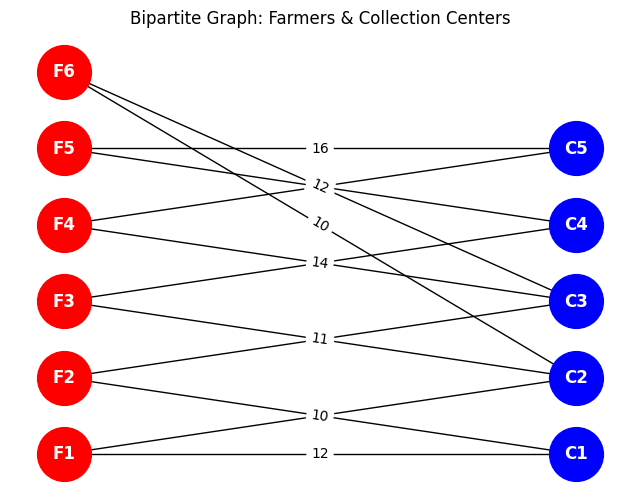

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
B = nx.Graph()

# Add nodes
farmers = ["F1", "F2", "F3", "F4", "F5", "F6"]
centers = ["C1", "C2", "C3", "C4", "C5"]

B.add_nodes_from(farmers, bipartite=0)
B.add_nodes_from(centers, bipartite=1)

# Add weighted edges
B.add_weighted_edges_from([
    ("F1","C1",12),
    ("F1","C2",8),
    ("F2","C1",10),
    ("F2","C3",15),
    ("F3","C2",11),
    ("F3","C4",9),
    ("F4","C3",14),
    ("F4","C5",13),
    ("F5","C4",8),
    ("F5","C5",16),
    ("F6","C2",10),
    ("F6","C3",12)
])

# Separate nodes
farmer_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == 0]
center_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == 1]

# Position
pos = {}
pos.update((n, (0, i)) for i, n in enumerate(farmer_nodes))
pos.update((n, (1, i)) for i, n in enumerate(center_nodes))

plt.figure(figsize=(8,6))

# Draw Farmers
nx.draw_networkx_nodes(
    B, pos,
    nodelist=farmer_nodes,
    node_color="red",
    node_size=1500
)

# Draw Collection Centers
nx.draw_networkx_nodes(
    B, pos,
    nodelist=center_nodes,
    node_color="blue",
    node_size=1500
)

# Draw edges
nx.draw_networkx_edges(B, pos)

# Draw labels
nx.draw_networkx_labels(
    B, pos,
    font_color="white",
    font_weight="bold"
)

# Draw edge weights
edge_labels = nx.get_edge_attributes(B, "weight")
nx.draw_networkx_edge_labels(B, pos, edge_labels=edge_labels)

plt.title("Bipartite Graph: Farmers & Collection Centers")
plt.axis("off")
plt.show()

**Part B:To study the collaboration between collection centers, create a projected graph in which two collection centers are connected if they receive produce from at least one common farmer.a) Construct the projected graph.b) Visualize the projected graph.c) Generate its adjacency matrix and adjacency list.**

In [ ]:
Part B:To study the collaboration between collection centers, create a projected graph in which two collection centers are connected if they receive produce from at least one common farmer.
a) Construct the projected graph.
b) Visualize the projected graph.
c) Generate its adjacency matrix and adjacency list.

In [6]:
#a) Construct the projected graph.
import networkx as nx

# Create Bipartite Graph
B = nx.Graph()

farmers = ["F1", "F2", "F3", "F4", "F5", "F6"]
centers = ["C1", "C2", "C3", "C4", "C5"]

B.add_nodes_from(farmers, bipartite=0)
B.add_nodes_from(centers, bipartite=1)

B.add_weighted_edges_from([
    ("F1","C1",12),
    ("F1","C2",8),
    ("F2","C1",10),
    ("F2","C3",15),
    ("F3","C2",11),
    ("F3","C4",9),
    ("F4","C3",14),
    ("F4","C5",13),
    ("F5","C4",8),
    ("F5","C5",16),
    ("F6","C2",10),
    ("F6","C3",12)
])

# Project onto Collection Centers
projected_graph = nx.bipartite.projected_graph(B, centers)

print("Projected Graph Edges:")
print(projected_graph.edges())

Projected Graph Edges:
[('C1', 'C3'), ('C1', 'C2'), ('C2', 'C3'), ('C2', 'C4'), ('C3', 'C5'), ('C4', 'C5')]


In [ ]:
(C1, C2)
(C1, C3)
(C2, C3)
(C2, C4)
(C3, C5)
(C4, C5)

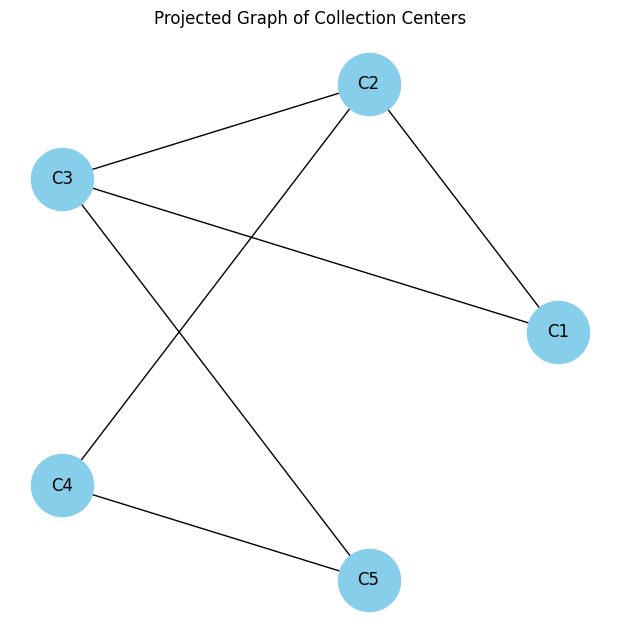

In [9]:
# b) Visualize the projected graph.
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

pos = nx.circular_layout(projected_graph)

nx.draw(
    projected_graph,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=2000,
    font_size=12
)

plt.title("Projected Graph of Collection Centers")
plt.show()

In [12]:
#c) Generate its adjacency matrix and adjacency list.
# Adjacency matrix
import pandas as pd

adj_matrix = nx.to_pandas_adjacency(projected_graph).astype(int)

print("Adjacency Matrix:")
print(adj_matrix)


# Adjacency list:
print("Adjacency List:")

for node in projected_graph.nodes():
    print(node, ":", list(projected_graph.neighbors(node)))

Adjacency Matrix:
    C1  C2  C3  C4  C5
C1   0   1   1   0   0
C2   1   0   1   1   0
C3   1   1   0   0   1
C4   0   1   0   0   1
C5   0   0   1   1   0
Adjacency List:
C1 : ['C3', 'C2']
C2 : ['C1', 'C3', 'C4']
C3 : ['C1', 'C2', 'C5']
C4 : ['C2', 'C5']
C5 : ['C3', 'C4']


In [ ]:
Part C:
Using the projected collection-center network:
a) Compute the shortest path lengths between all pairs of collection centers.
b) Calculate the eccentricity of each collection center.
c) Determine: Radius and Diameter
d) Determine whether the graph is planar.

In [13]:
# a) Compute the shortest path lengths between all pairs of collection centers.
# Shortest Path Lengths

shortest_paths = dict(nx.all_pairs_shortest_path_length(projected_graph))

print("Shortest Path Lengths:")

for source, paths in shortest_paths.items():
    print(source, ":", paths)

Shortest Path Lengths:
C1 : {'C1': 0, 'C3': 1, 'C2': 1, 'C5': 2, 'C4': 2}
C2 : {'C2': 0, 'C1': 1, 'C3': 1, 'C4': 1, 'C5': 2}
C3 : {'C3': 0, 'C1': 1, 'C2': 1, 'C5': 1, 'C4': 2}
C4 : {'C4': 0, 'C2': 1, 'C5': 1, 'C1': 2, 'C3': 2}
C5 : {'C5': 0, 'C3': 1, 'C4': 1, 'C1': 2, 'C2': 2}


In [15]:
#b) Calculate the eccentricity of each collection center.
eccentricity =nx.eccentricity(projected_graph)
print("Eccentricity: ",eccentricity)

Eccentricity:  {'C1': 2, 'C2': 2, 'C3': 2, 'C4': 2, 'C5': 2}


In [16]:
#c) Determine: Radius and Diameter
diameter = nx.diameter(projected_graph)
print("Diameter: ",diameter)
radius = nx.radius(projected_graph)
print("Radius: ",radius)


Diameter:  2
Radius:  2


In [17]:
# d) Determine whether the graph is planar
nx.is_planar(B)

True

In [ ]:
Part D:The agriculture authority defines a collection center as Critical if it is connected to three or more other collection centers in the projected graph; otherwise, it is Non-Critical.
a) Create the labels.
b) Train a Decision Tree or Logistic Regression classifier.
c) Evaluate the model using accuracy.

In [18]:
# a)Create the labels
import pandas as pd

# Create dataset
matrix = pd.DataFrame()

# Degree of each collection center
matrix["Degree"] = pd.Series(dict(projected_graph.degree()))

# Create labels
matrix["Label"] = matrix["Degree"].apply(
    lambda x: "Critical" if x >= 3 else "Non-Critical"
)

print(matrix)

    Degree         Label
C1       2  Non-Critical
C2       3      Critical
C3       3      Critical
C4       2  Non-Critical
C5       2  Non-Critical


In [19]:
#b) Train a Decision Tree or Logistic Regression classifier.
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Feature
X = matrix[["Degree"]]

# Convert labels to numbers
encoder = LabelEncoder()
y = encoder.fit_transform(matrix["Label"])

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [20]:
#c) Evaluate the model using accuracy.

from sklearn.metrics import accuracy_score

# Prediction
prediction = model.predict(X)

# Accuracy
accuracy = accuracy_score(y, prediction)

print("Accuracy =", accuracy)

Accuracy = 1.0
